# Speaker Recognition — CNV FINN Accelerator Inference on KV260

Run this notebook **on the Kria board** inside JupyterLab (port 9090).

This notebook is purpose-built for the CNV W4A4 model synthesised by
`FINN_Speaker_v2_ProvenArchitectures.ipynb`. It is **not compatible** with
the FC model — use the original `kria_inference.ipynb` for that.

### Architecture recap
```
Input (1, 1, 20, 64) NCHW
  → QuantIdentity (Int8, signed)
  → Conv2d(1→32, 3×3, pad=1) → BN → QuantReLU
  → Conv2d(32→32, 3×3, pad=1) → BN → QuantReLU → MaxPool(2,2)
  → Conv2d(32→64, 3×3, pad=1) → BN → QuantReLU
  → Conv2d(64→64, 3×3, pad=1) → BN → QuantReLU → MaxPool(2,2)
  → Flatten  →  5120
  → QuantLinear(5120→32) → QuantReLU
  → QuantLinear(32→NUM_CLASSES)
```

### Required directory layout (next to this notebook)
```
bitfile/
    finn-accel.bit
    finn-accel.hwh
driver.py
deploy_extras/
    X_test_q.npy        ← quantized test set, shape (N, 1, 20, 64), dtype int8
    y_test.npy          ← ground-truth labels, shape (N,), dtype int64
    input_scale.npy     ← [scale, zero_point] from QuantIdentity
    classes.json        ← metadata (class names, MFCC params, input shapes)
```
All files except `bitfile/` are generated by the FINN notebook's
**Section 7 — QONNX Export** deployment-artifacts cell.

---
## 0. Imports and configuration

In [1]:
import os, sys, json, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
HERE          = Path('.')           # directory containing this notebook
BITFILE       = HERE / 'bitfile' / 'finn-accel.bit'
DEPLOY_EXTRAS = HERE / 'deploy_extras'

assert BITFILE.exists(),            f'Bitfile not found: {BITFILE}'
assert DEPLOY_EXTRAS.exists(),      f'deploy_extras/ not found'
assert (HERE / 'driver.py').exists(), 'driver.py not found'

# ── Load metadata written by the FINN notebook ────────────────────────────────
with open(DEPLOY_EXTRAS / 'classes.json') as f:
    META = json.load(f)

CLASSES        = META['classes']
NUM_CLASSES    = META['num_classes']
USE_CHANNELS   = META['use_channels']      # 'I' or 'IQ'
N_MFCC         = META['n_mfcc']            # 20
MFCC_FRAMES    = META['mfcc_frames']       # 64
HOP_LENGTH     = META['hop_length']        # 2250
N_FFT          = META['n_fft']             # 2048
SAMPLING_FREQ  = META['sampling_freq']     # 48000
INPUT_CHANNELS = 1 if USE_CHANNELS == 'I' else 2
WEIGHT_BITS    = META['weight_bits']       # 4
ACT_BITS       = META['act_bits']          # 4

# CNV_INPUT_SHAPE is the exact shape the FINN driver DMA buffer expects.
# It must match the dummy input used in export_qonnx() in the FINN notebook:
#   torch.randn(1, INPUT_CHANNELS, N_MFCC, MFCC_FRAMES)
# and also the layout used when saving X_test_q.npy:
#   X_test_cnv_sel.transpose(0, 3, 1, 2)  →  (N, C, H, W)
CNV_INPUT_SHAPE = (1, N_MFCC, MFCC_FRAMES, INPUT_CHANNELS)  # (1, 20, 64, 1)
CNV_INPUT_ELEMS = int(np.prod(CNV_INPUT_SHAPE))              # 1280

# ── Load quantization parameters ─────────────────────────────────────────────
scale_arr   = np.load(DEPLOY_EXTRAS / 'input_scale.npy')
INPUT_SCALE = float(scale_arr[0])
INPUT_ZP    = float(scale_arr[1])

# ── Real-time budget: one inference per MFCC frame ────────────────────────────
FRAME_DURATION_MS = HOP_LENGTH / SAMPLING_FREQ * 1000   # 46.9 ms @ hop=2250, sr=48000

print('── CNV deployment metadata ──────────────────────────────────')
print(f'  Architecture   : CNV W{WEIGHT_BITS}A{ACT_BITS}  (BNN-PYNQ style)')
print(f'  Classes ({NUM_CLASSES})    : {CLASSES}')
print(f'  Channel mode   : {USE_CHANNELS} ({INPUT_CHANNELS} input channel(s))')
print(f'  CNV input shape: {CNV_INPUT_SHAPE}  — (batch, C, H=n_mfcc, W=frames)')
print(f'  Input elements : {CNV_INPUT_ELEMS} bytes per sample')
print(f'  Input scale    : {INPUT_SCALE:.6f}   zero_point: {INPUT_ZP}')
print(f'  MFCC params    : n_mfcc={N_MFCC}  frames={MFCC_FRAMES}  hop={HOP_LENGTH}  n_fft={N_FFT}')
print(f'  Sampling freq  : {SAMPLING_FREQ} Hz')
print(f'  Real-time budget per MFCC frame: {FRAME_DURATION_MS:.1f} ms')
print('─────────────────────────────────────────────────────────────')

── CNV deployment metadata ──────────────────────────────────
  Architecture   : CNV W4A4  (BNN-PYNQ style)
  Classes (10)    : ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005']
  Channel mode   : I (1 input channel(s))
  CNV input shape: (1, 20, 64, 1)  — (batch, C, H=n_mfcc, W=frames)
  Input elements : 1280 bytes per sample
  Input scale    : 0.043815   zero_point: 0.0
  MFCC params    : n_mfcc=20  frames=64  hop=2250  n_fft=2048
  Sampling freq  : 48000 Hz
  Real-time budget per MFCC frame: 46.9 ms
─────────────────────────────────────────────────────────────


---
## 1. Load the FINN accelerator overlay

In [2]:
sys.path.insert(0, str(HERE))

from driver import FINNExampleOverlay
import driver as _drv

print(f'Loading bitstream: {BITFILE.name} …')
t0 = time.time()

accel = FINNExampleOverlay(
    bitfile_name       = str(BITFILE),
    platform           = 'zynq-iodma',
    io_shape_dict      = getattr(__import__('driver'), 'io_shape_dict', {}),
    runtime_weight_dir = str(HERE / 'runtime_weights'),  # always a string; driver handles non-existent dir
)

print(f'Overlay loaded in {time.time()-t0:.1f} s')


Loading bitstream: finn-accel.bit …


Overlay loaded in 2.0 s


---
## 2. Inference helpers (CNV-specific)

All input data must reach the accelerator in **NCHW layout** —
`(1, INPUT_CHANNELS, N_MFCC, MFCC_FRAMES)` = `(1, 1, 20, 64)` for I-channel.

This matches exactly how `X_test_q.npy` was saved in the FINN notebook:
```python
X_test_cnv_nchw = X_test_cnv_sel.transpose(0, 3, 1, 2)   # NHWC → NCHW
```
and how the ONNX was exported:
```python
dummy_cnv = torch.randn(1, INPUT_CHANNELS, N_MFCC, MFCC_FRAMES)
export_qonnx(model_cnv_quant, dummy_cnv, ...)
```

In [3]:
def quantize_input(x_float: np.ndarray,
                   scale: float = INPUT_SCALE,
                   zero_point: float = INPUT_ZP) -> np.ndarray:
    """
    Replicate the Brevitas QuantIdentity (Int8ActPerTensorFloat) step.

    Formula: q = clip(round(x / scale) + zero_point, -128, 127)

    x_float must already be in NCHW layout: (1, C, N_MFCC, MFCC_FRAMES).
    Returns a uint8 array with the same shape — the int8 two's complement
    bit pattern is preserved; no data is changed, only the dtype annotation.
    """
    x_q = np.round(x_float / scale) + zero_point
    return np.clip(x_q, -128, 127).astype(np.int8).view(np.uint8)


def run_single(x_q: np.ndarray) -> int:
    # x_q arrives as NCHW-ordered bytes: (C, H, W) or (1, H, W) or (1,C,H,W)
    # Normalise to (C, H, W) first, then transpose to NHWC (H, W, C),
    # then add the batch dim → (1, H, W, C) = CNV_INPUT_SHAPE
    arr = x_q.view(np.uint8).reshape(INPUT_CHANNELS, N_MFCC, MFCC_FRAMES)  # (C,H,W)
    nhwc = arr.transpose(1, 2, 0)[np.newaxis]                               # (1,H,W,C)
    obuf = accel.execute([nhwc])
    return int(np.argmax(obuf[0].flatten()))


def run_batch(X_q: np.ndarray, batch_size: int = 1) -> np.ndarray:
    N    = X_q.shape[0]
    X_u8 = X_q.view(np.uint8) if X_q.dtype == np.int8 else X_q
    # Transpose entire array: NCHW (N,C,H,W) → NHWC (N,H,W,C)
    X_nhwc = X_u8.transpose(0, 2, 3, 1)   # (N, 20, 64, 1)
    preds  = np.zeros(N, dtype=np.int64)

    print(f'Running {N} samples (batch_size={batch_size}) …')
    t0 = time.perf_counter()

    for i in range(0, N, batch_size):
        batch = X_nhwc[i : i + batch_size]    # (batch_size, 20, 64, 1) — NHWC
        out   = accel.execute([batch])
        preds[i : i + batch_size] = np.argmax(
            out[0].reshape(batch_size, NUM_CLASSES), axis=1)
        if (i // batch_size) % 50 == 0:
            print(f'  {min(i+batch_size,N):>5}/{N}  ({time.perf_counter()-t0:.1f} s)', end='\r')

    elapsed = time.perf_counter() - t0
    print(f'\nDone — {N} samples in {elapsed:.2f} s  ({N/elapsed:.0f} samples/s)')
    return preds


print('Inference helpers defined.')
print(f'  CNV_INPUT_SHAPE : {CNV_INPUT_SHAPE}  (what the driver DMA buffer expects)')
print(f'  CNV_INPUT_ELEMS : {CNV_INPUT_ELEMS}  (bytes per sample)')
print(f'  INPUT_SCALE     : {INPUT_SCALE:.6f}')
print(f'  INPUT_ZP        : {INPUT_ZP}')

Inference helpers defined.
  CNV_INPUT_SHAPE : (1, 20, 64, 1)  (what the driver DMA buffer expects)
  CNV_INPUT_ELEMS : 1280  (bytes per sample)
  INPUT_SCALE     : 0.043815
  INPUT_ZP        : 0.0


---
## 3. Load pre-quantized test set and sanity-check one sample

`X_test_q.npy` was saved by the FINN notebook in **NCHW layout**:
```python
X_test_cnv_sel  = select_channels(X_test, USE_CHANNELS)    # (N, 20, 64, 1)
X_test_cnv_nchw = X_test_cnv_sel.transpose(0, 3, 1, 2)    # (N, 1, 20, 64)
X_test_cnv_q    = quantize_for_finn(X_test_cnv_nchw, ...)  # (N, 1, 20, 64) int8
```
The shape is `(N, 1, 20, 64)` — already in the exact format the driver expects.

In [4]:
print('Loading pre-quantized test set …')
X_test_q = np.load(DEPLOY_EXTRAS / 'X_test_q.npy')   # (N, 1, 20, 64)  int8
y_test   = np.load(DEPLOY_EXTRAS / 'y_test.npy')      # (N,)             int64

print(f'  X_test_q : {X_test_q.shape}  dtype={X_test_q.dtype}')
print(f'  y_test   : {y_test.shape}   dtype={y_test.dtype}')

# Verify NCHW layout is as expected — catches accidental re-generation
# with a different channel order or missing transpose step
NCHW_SHAPE = (INPUT_CHANNELS, N_MFCC, MFCC_FRAMES)          # (1, 20, 64)
assert X_test_q.shape[1:] == NCHW_SHAPE, (
    f'X_test_q has per-sample shape {X_test_q.shape[1:]} but expected NCHW {NCHW_SHAPE}.\n'
    f'Re-run the FINN notebook Section 7 deploy-artifacts cell to regenerate X_test_q.npy.')
assert int(np.prod(X_test_q.shape[1:])) == CNV_INPUT_ELEMS, \
    f'Element count mismatch: {int(np.prod(X_test_q.shape[1:]))} vs {CNV_INPUT_ELEMS}'
print(f'  ✓ X_test_q NCHW shape {X_test_q.shape[1:]} — {CNV_INPUT_ELEMS} elements per sample')
print(f'  ✓ Driver expects NHWC {CNV_INPUT_SHAPE} — transpose applied in run_batch/run_single')

# ── Single sample inference ───────────────────────────────────────────────────
sample_idx = 0
# X_test_q[sample_idx] is (1, 20, 64) int8; view as uint8 for DMA
x_sample   = X_test_q[sample_idx].view(np.uint8)
true_label = int(y_test[sample_idx])

print(f'\nRunning sample #{sample_idx} (true class: {CLASSES[true_label]}) …')
t_start = time.perf_counter()
pred    = run_single(x_sample)
t_end   = time.perf_counter()

latency_ms = (t_end - t_start) * 1000
correct    = '✓' if pred == true_label else '✗'

print(f'  Predicted : {CLASSES[pred]:>12}   True: {CLASSES[true_label]:>12}  {correct}')
print(f'  Latency   : {latency_ms:.2f} ms')

if pred != true_label and true_label == 0:
    print()
    print('NOTE: If the accelerator returns the same class for every sample,')
    print('      the streaming dataflow may be stalled. Run Section 7 diagnostics.')

Loading pre-quantized test set …
  X_test_q : (493, 1, 20, 64)  dtype=int8
  y_test   : (493,)   dtype=int64
  ✓ X_test_q NCHW shape (1, 20, 64) — 1280 elements per sample
  ✓ Driver expects NHWC (1, 20, 64, 1) — transpose applied in run_batch/run_single

Running sample #0 (true class: m0002) …
  Predicted :        m0002   True:        m0002  ✓
  Latency   : 9.52 ms


---
## 4. Batch accuracy on the full test set

In [5]:
# batch_size=1 is safest — matches RTL-sim validation during synthesis.
# Raise to 8 or 32 if your driver supports batched DMA.
y_pred   = run_batch(X_test_q, batch_size=1)
accuracy = np.mean(y_pred == y_test)

print(f'\nHardware accuracy : {accuracy*100:.2f}%  '
      f'({int(accuracy*len(y_test))}/{len(y_test)} correct)')

Running 493 samples (batch_size=1) …
    451/493  (3.6 s)
Done — 493 samples in 3.90 s  (127 samples/s)

Hardware accuracy : 97.97%  (483/493 correct)


---
## 5. Throughput and latency statistics

Per-sample latency over 200 runs
  Mean   : 7.715 ms
  Median : 7.690 ms
  P99    : 8.212 ms
  Min    : 7.651 ms
  Max    : 8.314 ms
  Throughput (1/mean) : 130 samples/s

Real-time budget (1 MFCC frame, hop=2250, sr=48000 Hz):
  Budget : 46.9 ms  →  ✓ accelerator is fast enough for real-time


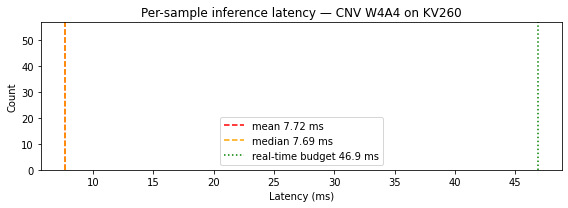

Saved: latency_histogram.png


In [6]:
N_REPS  = 200
# Slice [0:1] preserves the NCHW shape (1, 1, 20, 64) — unlike [0] which drops batch dim
x_bench = X_test_q[0:1].view(np.uint8).transpose(0, 2, 3, 1)  # (1, 20, 64, 1)

# Warm-up: prime the AXI DMA and PL pipeline
for _ in range(5):
    accel.execute([x_bench])

latencies = []
for _ in range(N_REPS):
    t = time.perf_counter()
    accel.execute(x_bench)
    latencies.append((time.perf_counter() - t) * 1000)

latencies = np.array(latencies)

print(f'Per-sample latency over {N_REPS} runs')
print(f'  Mean   : {latencies.mean():.3f} ms')
print(f'  Median : {np.median(latencies):.3f} ms')
print(f'  P99    : {np.percentile(latencies, 99):.3f} ms')
print(f'  Min    : {latencies.min():.3f} ms')
print(f'  Max    : {latencies.max():.3f} ms')
print(f'  Throughput (1/mean) : {1000/latencies.mean():.0f} samples/s')
print()
print(f'Real-time budget (1 MFCC frame, hop={HOP_LENGTH}, sr={SAMPLING_FREQ} Hz):')
rt_ok = latencies.mean() < FRAME_DURATION_MS
print(f'  Budget : {FRAME_DURATION_MS:.1f} ms  →  '
      f'{"✓ accelerator is fast enough for real-time" if rt_ok else "⚠ mean latency exceeds real-time budget"}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(latencies, bins=40, color='steelblue', edgecolor='white')
ax.axvline(latencies.mean(),     color='red',   linestyle='--',
           label=f'mean {latencies.mean():.2f} ms')
ax.axvline(np.median(latencies), color='orange', linestyle='--',
           label=f'median {np.median(latencies):.2f} ms')
ax.axvline(FRAME_DURATION_MS,    color='green',  linestyle=':',
           label=f'real-time budget {FRAME_DURATION_MS:.1f} ms')
ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Count')
ax.set_title(f'Per-sample inference latency — CNV W{WEIGHT_BITS}A{ACT_BITS} on KV260')
ax.legend()
plt.tight_layout()
plt.savefig('latency_histogram.png', dpi=120)
plt.show()
print('Saved: latency_histogram.png')

---
## 6. Confusion matrix and per-class accuracy

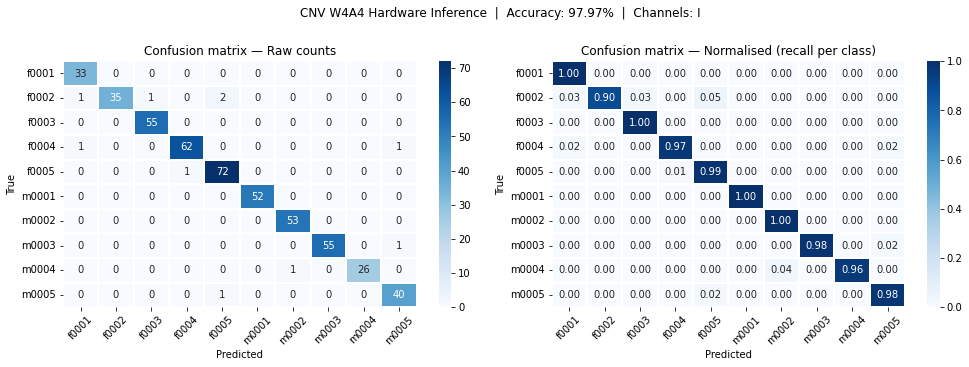

Saved: confusion_matrix.png

              precision    recall  f1-score   support

       f0001       0.94      1.00      0.97        33
       f0002       1.00      0.90      0.95        39
       f0003       0.98      1.00      0.99        55
       f0004       0.98      0.97      0.98        64
       f0005       0.96      0.99      0.97        73
       m0001       1.00      1.00      1.00        52
       m0002       0.98      1.00      0.99        53
       m0003       1.00      0.98      0.99        56
       m0004       1.00      0.96      0.98        27
       m0005       0.95      0.98      0.96        41

    accuracy                           0.98       493
   macro avg       0.98      0.98      0.98       493
weighted avg       0.98      0.98      0.98       493



In [7]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Raw counts', 'Normalised (recall per class)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                linewidths=0.3, cbar=True)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion matrix — {title}')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(
    f'CNV W{WEIGHT_BITS}A{ACT_BITS} Hardware Inference  |  '
    f'Accuracy: {accuracy*100:.2f}%  |  Channels: {USE_CHANNELS}',
    y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')
print('\n' + classification_report(y_test, y_pred, target_names=CLASSES))

---
## 10. Summary

In [8]:
print('╔' + '═'*66 + '╗')
print('║' + ' CNV Speaker Recognition — KV260 Deployment Results'.center(66) + '║')
print('╚' + '═'*66 + '╝')
print()
print(f'  Architecture   : CNV W{WEIGHT_BITS}A{ACT_BITS}  (BNN-PYNQ style)')
print(f'  Bitfile        : {BITFILE}')
print(f'  Channel mode   : {USE_CHANNELS} ({INPUT_CHANNELS} channel(s))')
print(f'  CNV input shape: {CNV_INPUT_SHAPE}  (1, C, N_MFCC, MFCC_FRAMES)')
print(f'  Input scale    : {INPUT_SCALE:.6f}   zero_point: {INPUT_ZP}')
print(f'  Classes        : {CLASSES}')
print()
print(f'  Test-set accuracy (pre-quantized) : {accuracy*100:.2f}%')
print(f'  Mean latency per sample           : {latencies.mean():.3f} ms')
print(f'  Throughput (1/mean latency)       : {1000/latencies.mean():.0f} samples/s')
print(f'  Real-time budget per MFCC frame   : {FRAME_DURATION_MS:.1f} ms')
rt_ok = latencies.mean() < FRAME_DURATION_MS
print(f'  Real-time capable                 : {"Yes ✓" if rt_ok else "No ⚠"}')
print()
print('  Outputs:')
print('    confusion_matrix.png   ← saved by Section 6')
print('    latency_histogram.png  ← saved by Section 5')
print('╚' + '═'*66 + '╝')

╔══════════════════════════════════════════════════════════════════╗
║        CNV Speaker Recognition — KV260 Deployment Results        ║
╚══════════════════════════════════════════════════════════════════╝

  Architecture   : CNV W4A4  (BNN-PYNQ style)
  Bitfile        : bitfile/finn-accel.bit
  Channel mode   : I (1 channel(s))
  CNV input shape: (1, 20, 64, 1)  (1, C, N_MFCC, MFCC_FRAMES)
  Input scale    : 0.043815   zero_point: 0.0
  Classes        : ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005']

  Test-set accuracy (pre-quantized) : 97.97%
  Mean latency per sample           : 7.715 ms
  Throughput (1/mean latency)       : 130 samples/s
  Real-time budget per MFCC frame   : 46.9 ms
  Real-time capable                 : Yes ✓

  Outputs:
    confusion_matrix.png   ← saved by Section 6
    latency_histogram.png  ← saved by Section 5
╚══════════════════════════════════════════════════════════════════╝
